EXPLORATORY ANALYSIS OF SPOTIFY DATASET


The objective of this analysis is to get to see how songs performs across .

ANALYSIS PROCEDURE;
1. Data cleaning and Initial Eploration

2. Exploratory Data Analysis and Visualisation of the basic statistics.

3. End goal analysis; Focus on the features of the most streamed songs.

In [118]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns



In [119]:
df = pd.read_csv('/home/georgyyy/Documents/python/GHHG/data.csv')

1. DATA CLEANING AND INITIAL EXPLORATION

In [120]:
df.head(3)

,artist and title,wks,t10,pk,x?,PkStreams,total,artist name,song name,lyrics
0,The Weeknd - Blinding Lights,347,64.0,1,(x13),52375259,5441240333,The Weeknd,Blinding Lights,Yeah I've been tryna call I've been on my own ...
1,Ed Sheeran - Shape of You,424,34.0,1,(x14),64217796,4470842634,Ed Sheeran,Shape of You,The club isn't the best place to find a lover ...
2,Harry Styles - As It Was,218,60.0,1,(x11),78460903,4417264164,Harry Styles,As It Was,﻿ As It Was - Harry Styles Come on Harry we wa...


In [121]:
df.tail(3)

,artist and title,wks,t10,pk,x?,PkStreams,total,artist name,song name,lyrics
8055,Ludacris - Good Lovin,1,NaN,223,NaN,174256,174256,Ludacris,Good Lovin,"I keep dwellin' on the past, babe Know what I ..."
8056,iSHi - Push It,1,NaN,236,NaN,173886,173886,iSHi,Push It,"Push it to the limit, if you wanna win it Harb..."
8057,Handsome Ghost - Steps,1,NaN,239,NaN,166910,166910,Handsome Ghost,Steps,"Over on your island, counting your clocks Mome..."


In [122]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8058 entries, 0 to 8057
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   artist and title  8058 non-null   str    
 1   wks               8058 non-null   int64  
 2   t10               810 non-null    float64
 3   pk                8058 non-null   int64  
 4   x?                334 non-null    str    
 5   PkStreams         8058 non-null   int64  
 6   total             8058 non-null   int64  
 7   artist name       8056 non-null   str    
 8   song name         8058 non-null   str    
 9   lyrics            8043 non-null   str    
dtypes: float64(1), int64(4), str(5)
memory usage: 629.7 KB


In [123]:
df.describe()

,wks,t10,pk,PkStreams,total
count,8058.000000,810.000000,8058.000000,8.058000e+03,8.058000e+03
mean,15.510549,8.209877,83.664185,1.156726e+07,1.419280e+08
std,30.921408,8.984420,60.125907,1.025781e+07,3.394366e+08
min,1.000000,1.000000,1.000000,1.669100e+05,1.669100e+05
25%,1.000000,1.000000,30.000000,5.368128e+06,8.916825e+06
50%,4.000000,5.000000,74.000000,8.941470e+06,2.798093e+07
75%,17.000000,13.000000,132.000000,1.414555e+07,1.188043e+08
max,457.000000,71.000000,246.000000,1.288961e+08,5.441240e+09


Due to poor column naming we would have to renname the column names then look for the number of duplicates and null entries and to also ease the understanding during visualisation

In [124]:
#column renaming
rename_mapping = {
    'artist and title': 'Artist and Title',
    'wks': 'Weeks_on_chart',
    't10': 'Weeks_on_top_10',
    'pk': 'Peak_Position',
    'x?': 'Weeks_at_peak_position',
    'PkStreams': 'Peak_Streams',
    'total': 'Total_Streams',
    'artist name': 'Artist_Name',
    'song name': 'Track_Name',
    'lyrics': 'Lyrics'
}

df.rename(columns=rename_mapping, inplace=True)

Checking for duplicates and null entries if any we drop the duplicates and fill in the null data with the median entry for the numerical column and drop ones that have no  key metrics required to achieve our end goal ;artist names.

In [125]:
# checking for duplicates 
duplicate_entries = df.duplicated().sum()
print("Number of duplicated entries:", duplicate_entries)    

Number of duplicated entries: 0


In [126]:
null_entries = df.isnull().sum()
null_entries = null_entries[null_entries > 0].sort_values(ascending=False)  
print("Columns with missing values:\n", null_entries)

Columns with missing values:
 Weeks_at_peak_position    7724
Weeks_on_top_10           7248
Lyrics                      15
Artist_Name                  2
dtype: int64


FILLING NULL ENTRIES


For numerical columns I used the median values to fill in null columns so as to avoid outliers in the case of mean.

For categorical columns I filled the entries with "unknown"


In [127]:
num_columns= ['Weeks_on_chart', 'Weeks_on_top_10', 'Peak_Position', 'Peak_Streams', 'Total_Streams']
clean_num = df[num_columns].fillna(df[num_columns].median())


display(clean_num)

,Weeks_on_chart,Weeks_on_top_10,Peak_Position,Peak_Streams,Total_Streams
0,347,64.0,1,52375259,5441240333
1,424,34.0,1,64217796,4470842634
2,218,60.0,1,78460903,4417264164
3,333,5.0,16,21624450,4142643719
4,343,15.0,4,24962682,3933581891
...,...,...,...,...,...
8053,1,5.0,220,177495,177495
8054,1,5.0,234,176713,176713
8055,1,5.0,223,174256,174256
8056,1,5.0,236,173886,173886


In [128]:
cat_columns = ['Artist and Title', 'Artist_Name', 'Track_Name', 'Lyrics']
clean_cat = df[cat_columns].fillna('Unknown')

display(clean_cat)

,Artist and Title,Artist_Name,Track_Name,Lyrics
0,The Weeknd - Blinding Lights,The Weeknd,Blinding Lights,Yeah I've been tryna call I've been on my own ...
1,Ed Sheeran - Shape of You,Ed Sheeran,Shape of You,The club isn't the best place to find a lover ...
2,Harry Styles - As It Was,Harry Styles,As It Was,﻿ As It Was - Harry Styles Come on Harry we wa...
3,The Neighbourhood - Sweater Weather,The Neighbourhood,Sweater Weather,And all I am is a man I want the world in my h...
4,Lewis Capaldi - Someone You Loved,Lewis Capaldi,Someone You Loved,I'm going under and this time I fear there's n...
...,...,...,...,...
8053,Mariah Carey - Infinity,Mariah Carey,Infinity,Why you mad? Talking about you mad Could it be...
8054,Twenty One Pilots - Fairly Local,Twenty One Pilots,Fairly Local,"I'm fairly local, I've been around I've seen t..."
8055,Ludacris - Good Lovin,Ludacris,Good Lovin,"I keep dwellin' on the past, babe Know what I ..."
8056,iSHi - Push It,iSHi,Push It,"Push it to the limit, if you wanna win it Harb..."


EXPLORATORY ANALYSIS


Through out this stage we would look at the basic statistics that would help us to achieve our main aim for the analysis


1. BASIC STATISTICS - OVERVIEW

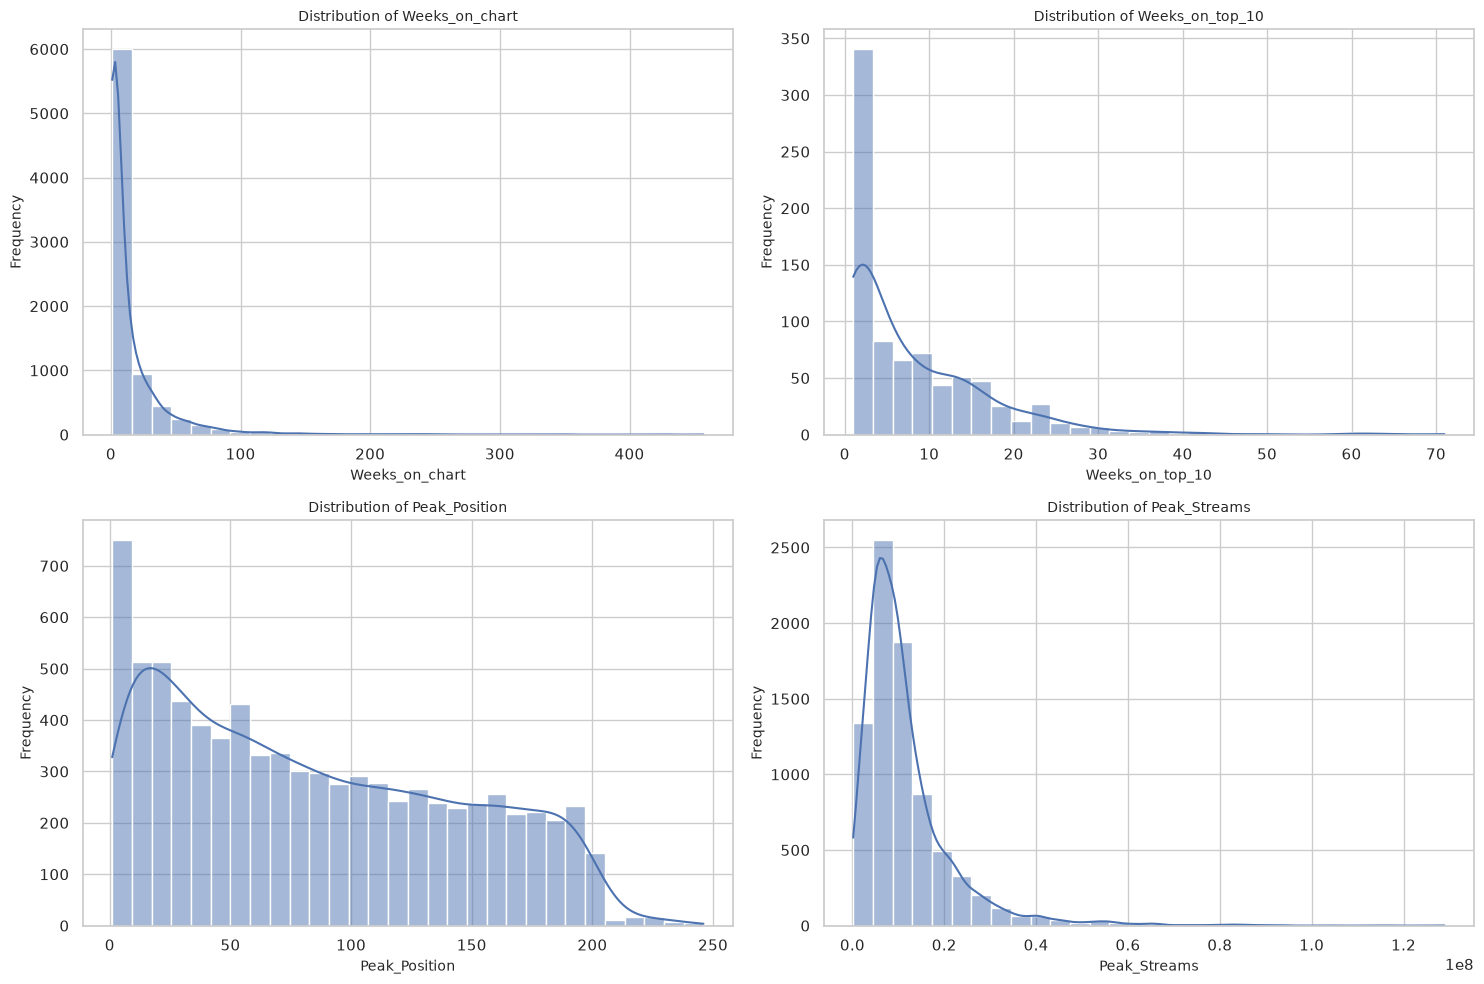

In [129]:




fig, ax = plt.subplots(2,2,figsize=(15, 10))

ax.flatten()

plot_columns = ['Weeks_on_chart', 'Weeks_on_top_10', 'Peak_Position', 'Peak_Streams', 'Total_Streams']  

for i, col in enumerate(plot_columns[:4]):
    sns.histplot(data=df, x=col, ax=ax.flatten()[i], kde=True, color='b', bins=30)
    ax.flatten()[i].set_title(f'Distribution of {col}', fontsize=10)
    ax.flatten()[i].set_xlabel(col, fontsize=10)
    ax.flatten()[i].set_ylabel('Frequency', fontsize=10)

plt.tight_layout()

sns.set(style="whitegrid")



TOP SONGS BY TOTAL STREAMS

Top 10 Songs by Total Streams:


,Artist_Name,Track_Name,Total_Streams
0,The Weeknd,Blinding Lights,5441240333
1,Ed Sheeran,Shape of You,4470842634
2,Harry Styles,As It Was,4417264164
3,The Neighbourhood,Sweater Weather,4142643719
4,Lewis Capaldi,Someone You Loved,3933581891
5,The Weeknd,Starboy,3857210959
6,Billie Eilish,BIRDS OF A FEATHER,3821072735
7,Lady Gaga,Die With A Smile,3797546382
8,Post Malone,Sunflower,3793341693
9,Ed Sheeran,Perfect,3730229095


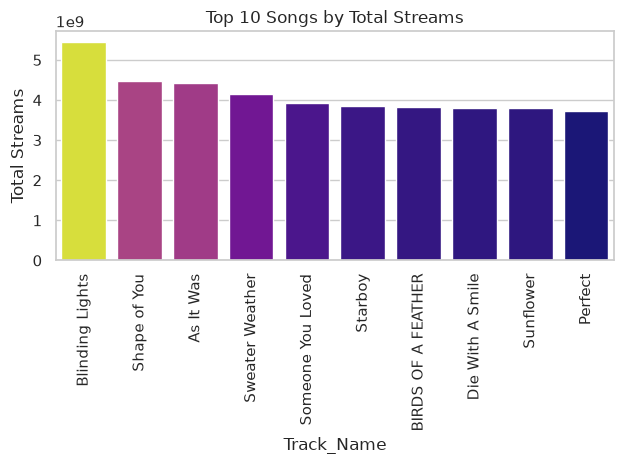

In [130]:
top10 = df.sort_values('Total_Streams', ascending=False).head(10)
sns.barplot(x='Track_Name', y='Total_Streams', data=top10,hue='Total_Streams' ,palette='plasma' ,legend=False)
plt.title('Top 10 Songs by Total Streams')
plt.xlabel('Track_Name')
plt.ylabel('Total Streams') 
plt.xticks(rotation=90)
plt.tight_layout()
sort_stream = df.sort_values(by='Total_Streams', ascending=False)

print("Top 10 Songs by Total Streams:")

display(sort_stream[['Artist_Name', 'Track_Name', 'Total_Streams']].head(10))

SONG TIER CATEGORISATION 

In [131]:


def hit_cat(position):
    if position == 1:
        return 'Hit'
    elif position <= 10:
        return 'Top 10'
    elif position <= 50:
        return 'Top 50'
    else:
        return 'Mid'

df['Category'] = df['Peak_Position'].apply(hit_cat)
print("Top Songs by Category:")
display(df[['Artist_Name', 'Track_Name', 'Peak_Position', 'Category']].head(10))

Top Songs by Category:


,Artist_Name,Track_Name,Peak_Position,Category
0,The Weeknd,Blinding Lights,1,Hit
1,Ed Sheeran,Shape of You,1,Hit
2,Harry Styles,As It Was,1,Hit
3,The Neighbourhood,Sweater Weather,16,Top 50
4,Lewis Capaldi,Someone You Loved,4,Top 10
5,The Weeknd,Starboy,1,Hit
6,Billie Eilish,BIRDS OF A FEATHER,1,Hit
7,Lady Gaga,Die With A Smile,1,Hit
8,Post Malone,Sunflower,1,Hit
9,Ed Sheeran,Perfect,4,Top 10


FINDING THE ARTIST WITH THE MOST HITS SONGS IN THE CHART

In [132]:
hit_counts = df[df['Category']=='Hit']
artist_hits = (
            hit_counts['Artist_Name']
            .value_counts()
            .rename_axis('Artist-Name')
            .reset_index(name='Hit_counts')

)        

# df['Hits_count'] = df['Artist_Name'].map(
#     artist_hits.set_Index('Artist_Name')['Hit_Count']
# )

artist_hits.head(10)


,Artist-Name,Hit_counts
0,Taylor Swift,8
1,Ariana Grande,6
2,Drake,5
3,Bad Bunny,5
4,Justin Bieber,5
5,The Weeknd,4
6,Post Malone,4
7,Olivia Rodrigo,4
8,Ed Sheeran,3
9,Billie Eilish,3


ARTIST RANKING BY TOTAL STREAMS

In [133]:


if "Artist_Name" in df.columns:
    artist_streams = (
        df.groupby("Artist_Name", as_index=False)["Total_Streams"]
        .sum()
        .sort_values("Total_Streams", ascending=False)
        .head(20)
    )
else:
    artist_streams = pd.DataFrame(columns=["Artist_Name", "Total_Streams"])

print("\nTop 10 artists by total streams:")
display(artist_streams.head(10))



Top 10 artists by total streams:


,Artist_Name,Total_Streams
161,Bad Bunny,31134387025
1581,The Weeknd,29875176511
1533,Taylor Swift,26273874386
438,Drake,22740546162
204,Billie Eilish,21972201869
456,Ed Sheeran,21777307945
1292,Post Malone,19237721490
120,Ariana Grande,15600211489
785,Justin Bieber,13990423095
244,Bruno Mars,12281748644


Average artist Streams: 15928924204.4


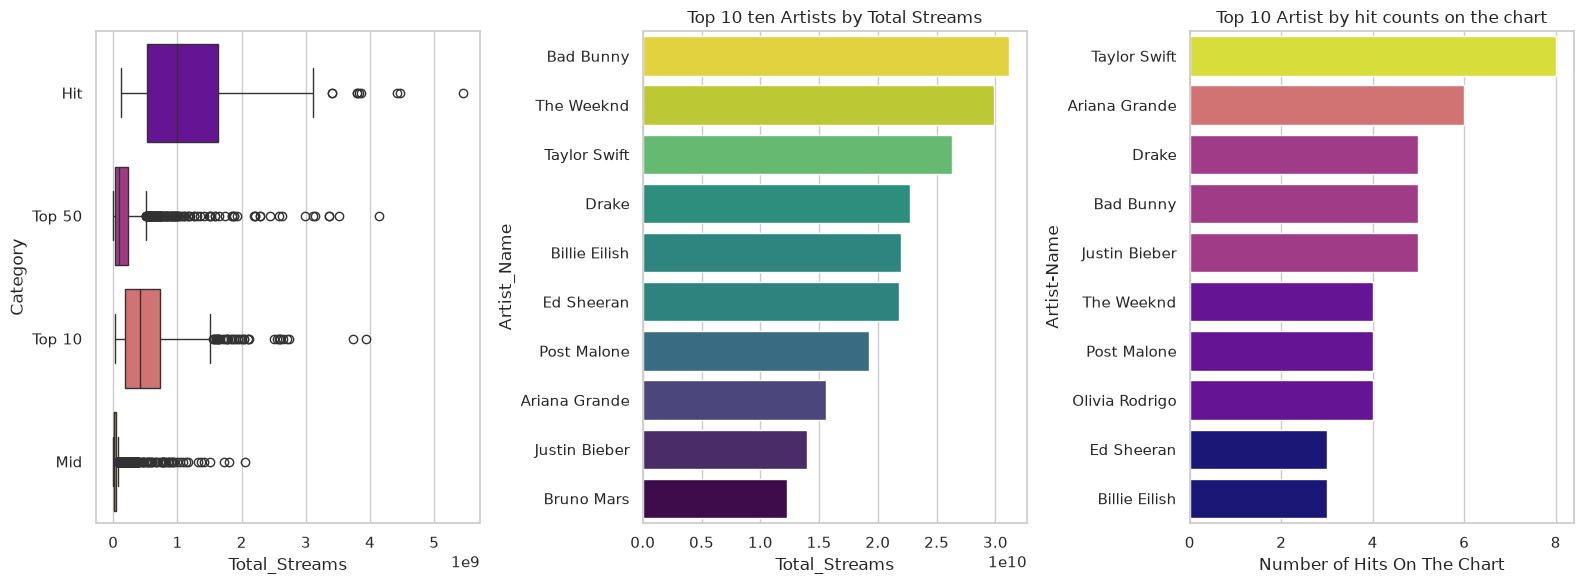

In [134]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

sns.barplot(
	data=artist_hits.head(10),
	x='Hit_counts',
	y='Artist-Name',
	hue='Hit_counts',	palette='plasma',
	ax=axes[2] ,
    legend=False
    
)




sns.boxplot(
	data=df,
	x='Total_Streams',
	y='Category',
	hue='Category',
	palette='plasma',
	ax=axes[0]
)

sns.barplot(
	data=artist_streams.head(10),
	x='Total_Streams',
	y='Artist_Name',
    hue='Total_Streams',
	palette='viridis',
	ax=axes[1],
    legend=False
)
axes[2].set_xlabel( 'Number of Hits On The Chart')
axes[2].set_title("Top 10 Artist by hit counts on the chart")
axes[1].set_title("Top 10 ten Artists by Total Streams")
axes[0].set_xlabel('Total_Streams')
axes[0].set_ylabel('Category')
axes[1].set_xlabel('Total_Streams')
axes[1].set_ylabel('Artist_Name')
plt.tight_layout()

avg_streams = artist_streams['Total_Streams'].mean()
print("Average artist Streams:" ,avg_streams )

STREAMS DISTRIBUTION ACROSS THE 4 CATEGORIES

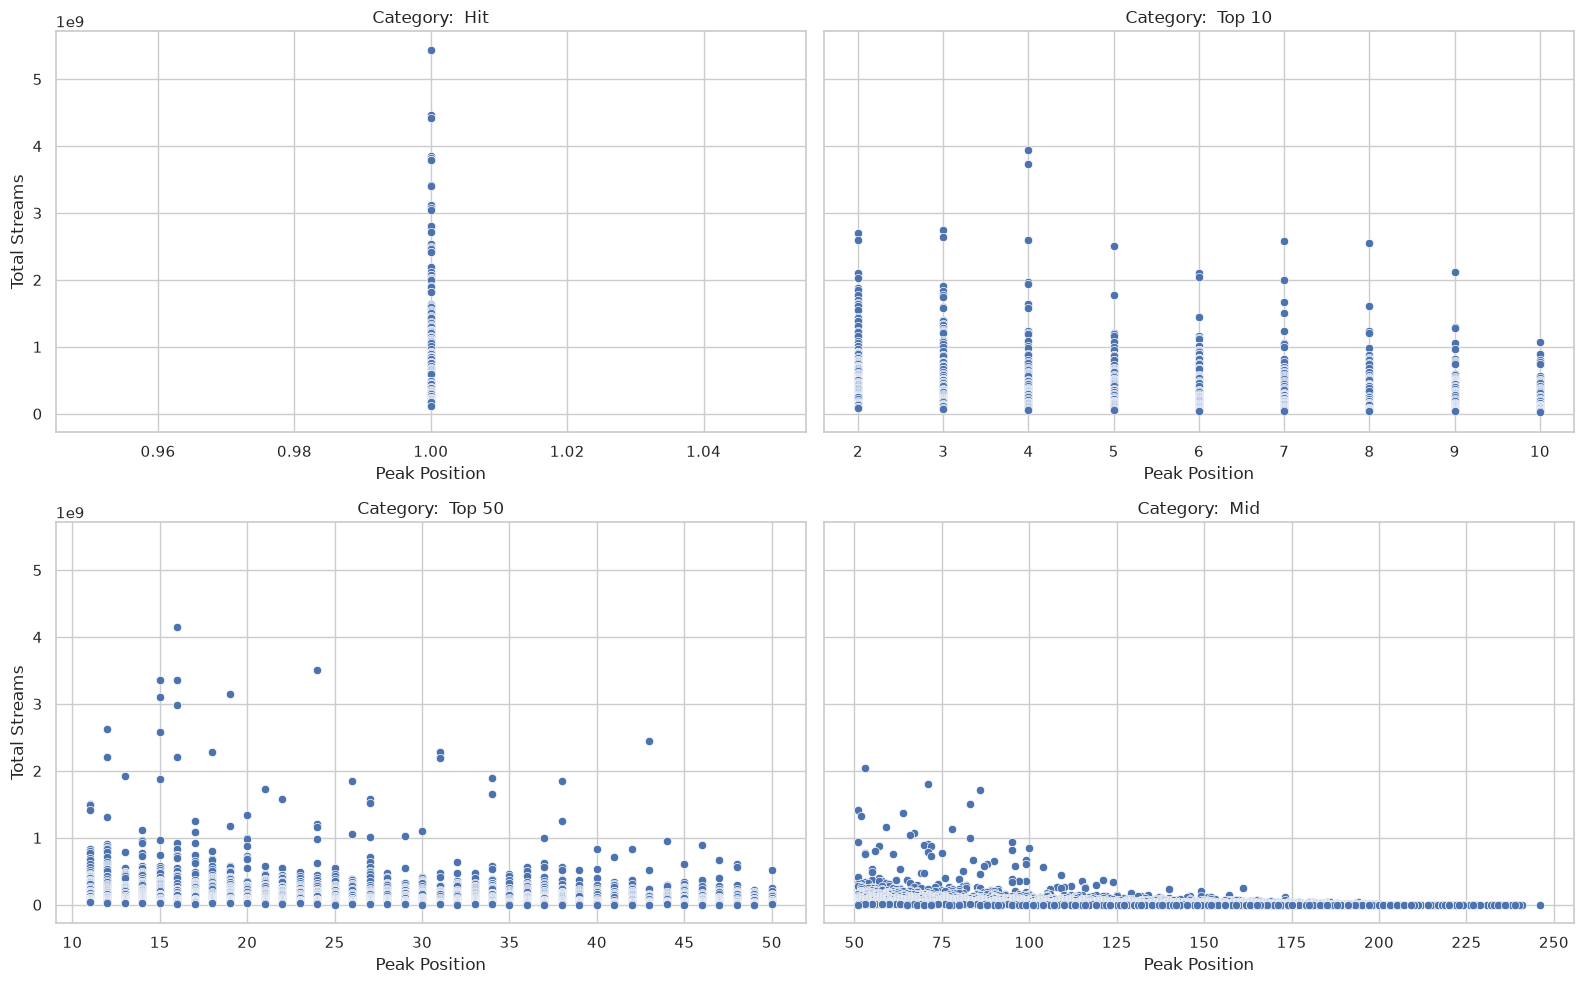

In [135]:
cats_4 = ['Hit', 'Top 10', 'Top 50', 'Mid']


fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
axes=axes.flatten()

for i, cat in enumerate(cats_4):
    df2 =df[df['Category']== cat]
    sns.scatterplot(
        data=df2,
        x = 'Peak_Position',
        y='Total_Streams',
        ax =axes[i],
    
        
    )

    axes[i].set_title(f'Category:  {cat}')
    axes[i].set_xlabel('Peak Position')
    axes[i].set_ylabel('Total Streams')

    plt.tight_layout()

LYRICAL ANALYSIS.


Lyrics statistics:
       lyrics_length    word_count
count    8058.000000   8058.000000
mean     2034.295607    403.228220
std      1197.301794    232.315049
min         0.000000      0.000000
25%      1395.250000    280.000000
50%      1857.000000    370.000000
75%      2455.750000    486.000000
max     65511.000000  12518.000000


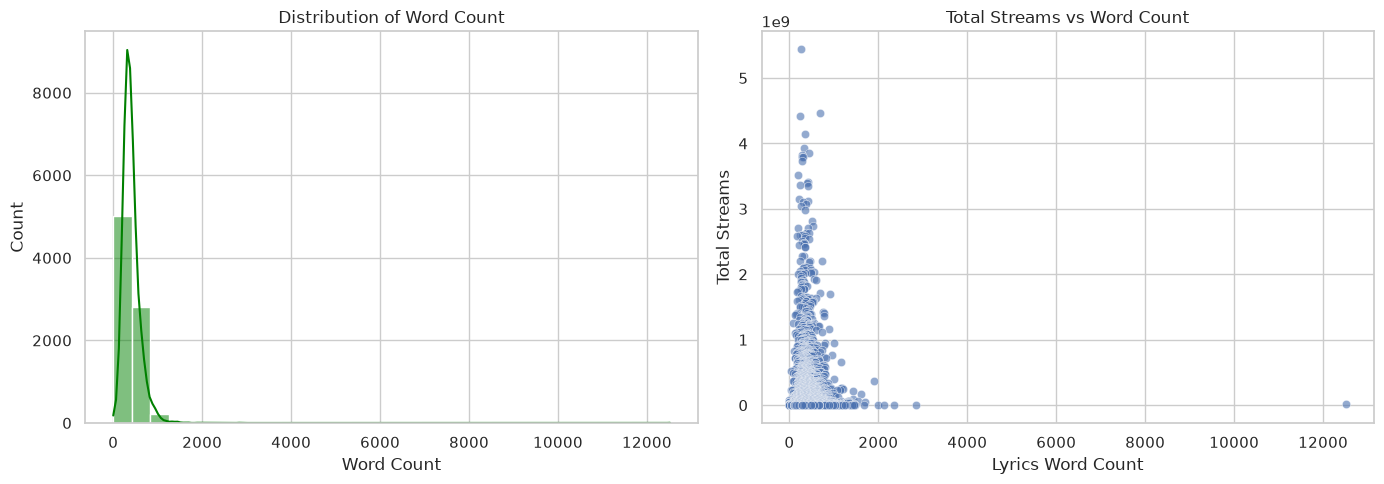

In [155]:
if "Lyrics" in df.columns:
    df["lyrics_length"] = df["Lyrics"].fillna("").str.len()
    df["word_count"] = df["Lyrics"].fillna("").str.split().str.len()

    print("\nLyrics statistics:")
    print(df[["lyrics_length", "word_count"]].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["word_count"], bins=30, kde=True, ax=axes[0], color="green")
axes[0].set_title("Distribution of Word Count")
axes[0].set_xlabel("Word Count")

sns.scatterplot(
    data=df,
    x="word_count",
    y="Total_Streams",
    ax=axes[1],
    alpha=0.6,
)
axes[1].set_title("Total Streams vs Word Count")
axes[1].set_xlabel("Lyrics Word Count")
axes[1].set_ylabel("Total Streams")

plt.tight_layout()
plt.show()

INSIGHTS FROM THE ANALYSIS

1. Hit songs stream the most  at around 1 billion streams per week while most Top 10  song avarage under 500 Million streams with a few outliers reaching 3.5Billion streams.

2. Insights from the Histogram visuals for distribution:

        From weeks_on_chart distribution ; Most song stay less than 3 weeks on the chart.
        From weeks_on_top_ 10 chart; Most songs spend less than  5 weeks in the topy 10 before dropping.
        From Peak_Position chart; Most songs peak at around the top 10 while a few songs peak at around the baseline of the charts.

 Rapid turnovers overtime.
 Short lived engagement by the audiences around the baseline of the charts.



 LYRICAL WORD COUNT STATISTICS.
   Most people  prefer short songs avaraging around 2-3 minutes; Most Hit songs avarage  word counts below 500.

